# PCA Project - Iris Dataset

The goal of this project is to use Scikit-Learn's and from scratch **models** to implement a machine learning project using Scikit-Learn's Iris dataset.

## 1. Imports

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as PCASklearn

from pca import PCA as PCAScratch

## 2. Load dataset

In [3]:
df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)
df['target'] = load_iris().target 

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (150, 5)
Head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Description:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000 

The four features have the same unit (cm), but they do not have the same variance, so we standardize the dataset.

Without standardization, PCA would overemphasize the features with the highest variance, regardless of their actual importance.

In [6]:
# Prepare the data: keep features
X = df.drop("target", axis=1).values # features
y_true = df["target"].values # target

In [7]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. PCA: Scratch Implementation

In [8]:
pca_scratch = PCAScratch(n_components=2)

In [9]:
Z_scratch = pca_scratch.fit_transform(X_scaled)

In [10]:
print("Scratch Explained Variance Ratio =", pca_scratch.explained_variance_ratio_)
print("Scratch Components =", pca_scratch.components_)
print("Scratch Projection Matrix Shape:", Z_scratch.shape)

Scratch Explained Variance Ratio = [0.72962445 0.22850762]
Scratch Components = [[-0.52106591  0.37741762]
 [ 0.26934744  0.92329566]
 [-0.5804131   0.02449161]
 [-0.56485654  0.06694199]]
Scratch Projection Matrix Shape: (150, 2)


## 4. PCA Scikit-Learn Implementation

In [11]:
pca_sklearn = PCASklearn(n_components=2)

In [12]:
Z_sklearn = pca_sklearn.fit_transform(X_scaled)

In [13]:
print("Sklearn Explained Variance Ratio =", pca_sklearn.explained_variance_ratio_)
print("Sklearn Components =", pca_sklearn.components_)
print("Sklearn Projection Matrix Shape:", Z_sklearn.shape)

Sklearn Explained Variance Ratio = [0.72962445 0.22850762]
Sklearn Components = [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]
Sklearn Projection Matrix Shape: (150, 2)


We notice **identical explained variance ratio**: 72.9% + 22.9% = 95.8% of the total variance captured by two components.

The components have opposite signs in sklearn versus scratch, this is the expected behavior: an eigenvector and its opposite are mathematically equivalent.

## 5. Cumulative Variance plot

In [22]:
# Scratch variables
explained_var_scratch = pca_scratch.explained_variance_ratio_
n_components = len(explained_var_scratch)  
cumulative_var = np.cumsum(explained_var_scratch)

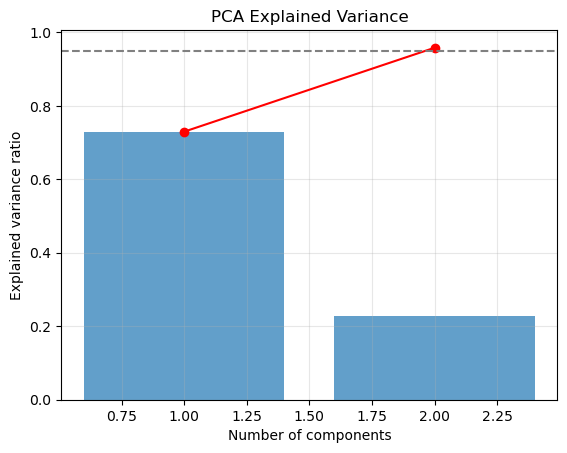

In [23]:
fig, ax = plt.subplots()

# Bar chart: individual ratio by component
ax.bar(
    range(1, n_components + 1),
    explained_var_scratch,
    alpha=0.7,
    label='Individual explained variance'
)

# Cumulative line
ax.plot(
    range(1, n_components + 1),
    cumulative_var,
    marker='o',
    color='red',
    label='Cumulative explained variance'
)

ax.axhline(y=0.95, linestyle='--', color='gray', label='95% threshold')  # 95% threshold
ax.set_xlabel('Number of components')
ax.set_ylabel('Explained variance ratio')
ax.set_title('PCA Explained Variance')
ax.grid(True, alpha=0.3)
plt.show()

### PCA Explained Variance Analysis

The first principal component explains approximately **73%** of the total variance, indicating that most of the information in the dataset can already be captured along a single principal axis.

The second principal component contributes an additional **23%** of explained variance, bringing the cumulative explained variance to approximately **96%**.

The cumulative explained variance curve shows that retaining both principal components preserves more than **95%** of the original dataset's information, which is a commonly used threshold for dimensionality reduction.

In this case, since the original dataset contains only two features, PCA does not lead to a significant dimensionality reduction. However, the results indicate that the **first principal component captures the dominant structure of the data**, while the second component contributes a smaller amount of additional information.

Overall, this suggests that the dataset can be effectively represented in a lower-dimensional space, with most of its variability concentrated along the first principal axis.